In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# Load news dataset
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv', index_col=0)

# Parse dates
news_df['date'] = pd.to_datetime(news_df['date'], utc=True, errors='coerce')
news_df = news_df.dropna(subset=['date'])
news_df['date'] = news_df['date'].dt.tz_localize(None)
news_df['trading_date'] = news_df['date'].dt.normalize()

print(f"✅ News data loaded! Shape: {news_df.shape}")
print(f"Columns: {list(news_df.columns)}")
print(f"Date range: {news_df['trading_date'].min().date()} to {news_df['trading_date'].max().date()}")

✅ News data loaded! Shape: (55987, 6)
Columns: ['headline', 'url', 'publisher', 'date', 'stock', 'trading_date']
Date range: 2011-04-28 to 2020-06-11


In [3]:
# Load all 5 stock CSV files
stocks = {
    'AAPL': '../data/raw/AAPL.csv',
    'AMZN': '../data/raw/AMZN.csv',
    'GOOG': '../data/raw/GOOG.csv',
    'META': '../data/raw/META.csv',
    'NVDA': '../data/raw/NVDA.csv'
}

stock_dfs = {}
for symbol, path in stocks.items():
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    df.index = df.index.tz_localize(None)
    df = df.sort_index()
    df = df.dropna()
    # Compute daily return using Adj Close if available else Close
    df['Daily_Return'] = df['Close'].pct_change() * 100
    df = df.dropna()
    stock_dfs[symbol] = df
    print(f"✅ {symbol}: {len(df)} trading days | {df.index[0].date()} to {df.index[-1].date()}")

print(f"\n✅ All stock data loaded!")

✅ AAPL: 3773 trading days | 2009-01-05 to 2023-12-29
✅ AMZN: 3773 trading days | 2009-01-05 to 2023-12-29
✅ GOOG: 3773 trading days | 2009-01-05 to 2023-12-29
✅ META: 2922 trading days | 2012-05-21 to 2023-12-29
✅ NVDA: 3773 trading days | 2009-01-05 to 2023-12-29

✅ All stock data loaded!


In [4]:
# Filter news for our stocks
# Note: META was listed as FB before 2021
our_symbols = ['AAPL', 'AMZN', 'GOOG', 'GOOGL', 'NVDA', 'META', 'FB']

filtered_news = news_df[news_df['stock'].isin(our_symbols)].copy()

# Standardize symbols
filtered_news['stock'] = filtered_news['stock'].replace({
    'GOOGL': 'GOOG',
    'FB': 'META'
})

print(f"✅ Filtered news shape: {filtered_news.shape}")
print(f"\nArticles per stock:")
print(filtered_news['stock'].value_counts())
print(f"\nDate range: {filtered_news['trading_date'].min().date()} to {filtered_news['trading_date'].max().date()}")

✅ Filtered news shape: (60, 6)

Articles per stock:
stock
GOOG    20
AAPL    10
AMZN    10
META    10
NVDA    10
Name: count, dtype: int64

Date range: 2020-05-31 to 2020-06-10


In [5]:
# Initialize VADER
# We use VADER because:
# - Specifically designed for short text like news headlines
# - No training required
# - Returns compound score between -1 (negative) and +1 (positive)
# - Handles financial language well

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(headline):
    try:
        return analyzer.polarity_scores(str(headline))['compound']
    except:
        return 0.0

def classify_sentiment(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply sentiment scoring
filtered_news['sentiment_score'] = filtered_news['headline'].apply(get_sentiment)
filtered_news['sentiment_label'] = filtered_news['sentiment_score'].apply(classify_sentiment)

print("✅ Sentiment analysis complete!")
print(f"\nSentiment score statistics:")
print(filtered_news['sentiment_score'].describe().round(4))
print(f"\nSentiment distribution:")
print(filtered_news['sentiment_label'].value_counts())

✅ Sentiment analysis complete!

Sentiment score statistics:
count    60.0000
mean      0.1526
std       0.3912
min      -0.8402
25%       0.0000
50%       0.0000
75%       0.5185
max       0.7296
Name: sentiment_score, dtype: float64

Sentiment distribution:
sentiment_label
positive    29
neutral     25
negative     6
Name: count, dtype: int64


In [6]:
# If multiple articles on same day for same stock
# → compute average daily sentiment score
daily_sentiment = filtered_news.groupby(
    ['stock', 'trading_date']
).agg(
    avg_sentiment=('sentiment_score', 'mean'),
    article_count=('headline', 'count'),
    sentiment_label=('sentiment_label', lambda x: x.mode()[0])
).reset_index()

print(f"✅ Daily sentiment aggregated!")
print(f"Shape: {daily_sentiment.shape}")
print(f"\nSample:")
print(daily_sentiment.head(10))

✅ Daily sentiment aggregated!
Shape: (18, 5)

Sample:
  stock trading_date  avg_sentiment  article_count sentiment_label
0  AAPL   2020-06-09       0.246900              4         neutral
1  AAPL   2020-06-10       0.198850              6        positive
2  AMZN   2020-06-09       0.077775              4        positive
3  AMZN   2020-06-10       0.391233              6        positive
4  GOOG   2020-06-04       0.000000              3         neutral
5  GOOG   2020-06-05      -0.411033              6        negative
6  GOOG   2020-06-07       0.000000              1         neutral
7  GOOG   2020-06-08       0.542300              2        positive
8  GOOG   2020-06-09       0.000000              3         neutral
9  GOOG   2020-06-10       0.319420              5        positive


In [7]:
# Combine all stock daily returns into one dataframe
returns_list = []

for symbol, df in stock_dfs.items():
    temp = df[['Daily_Return']].copy()
    temp['stock'] = symbol
    temp['trading_date'] = temp.index
    temp = temp.reset_index(drop=True)
    returns_list.append(temp)

all_returns = pd.concat(returns_list, ignore_index=True)
all_returns['trading_date'] = pd.to_datetime(all_returns['trading_date'])

print(f"✅ Combined returns shape: {all_returns.shape}")
print(f"\nReturns per stock:")
print(all_returns['stock'].value_counts())
print(f"\nSample:")
print(all_returns.head(10))

✅ Combined returns shape: (18014, 3)

Returns per stock:
stock
AAPL    3773
AMZN    3773
GOOG    3773
NVDA    3773
META    2922
Name: count, dtype: int64

Sample:
   Daily_Return stock trading_date
0      4.220416  AAPL   2009-01-05
1     -1.649399  AAPL   2009-01-06
2     -2.160860  AAPL   2009-01-07
3      1.856959  AAPL   2009-01-08
4     -2.286921  AAPL   2009-01-09
5     -2.119649  AAPL   2009-01-12
6     -1.071572  AAPL   2009-01-13
7     -2.713489  AAPL   2009-01-14
8     -2.285260  AAPL   2009-01-15
9     -1.259246  AAPL   2009-01-16


In [8]:
# ============================================
# DATE ALIGNMENT
# Articles published on weekends or holidays
# are aligned to the next trading day
# ============================================

def align_to_trading_day(date, trading_days):
    """Move weekend/holiday dates to next trading day"""
    date = pd.Timestamp(date)
    if date in trading_days:
        return date
    future_days = trading_days[trading_days > date]
    if len(future_days) > 0:
        return future_days[0]
    return None

# Get all unique trading days from stock data
all_trading_days = pd.DatetimeIndex(
    sorted(all_returns['trading_date'].unique())
)

# Apply alignment to news dates
daily_sentiment['aligned_date'] = daily_sentiment['trading_date'].apply(
    lambda x: align_to_trading_day(x, all_trading_days)
)

daily_sentiment = daily_sentiment.dropna(subset=['aligned_date'])

print(f"✅ Date alignment complete!")
print(f"Records after alignment: {len(daily_sentiment)}")
print(f"\nSample aligned dates:")
print(daily_sentiment[['stock', 'trading_date', 'aligned_date', 'avg_sentiment']].head(10))

✅ Date alignment complete!
Records after alignment: 18

Sample aligned dates:
  stock trading_date aligned_date  avg_sentiment
0  AAPL   2020-06-09   2020-06-09       0.246900
1  AAPL   2020-06-10   2020-06-10       0.198850
2  AMZN   2020-06-09   2020-06-09       0.077775
3  AMZN   2020-06-10   2020-06-10       0.391233
4  GOOG   2020-06-04   2020-06-04       0.000000
5  GOOG   2020-06-05   2020-06-05      -0.411033
6  GOOG   2020-06-07   2020-06-08       0.000000
7  GOOG   2020-06-08   2020-06-08       0.542300
8  GOOG   2020-06-09   2020-06-09       0.000000
9  GOOG   2020-06-10   2020-06-10       0.319420


In [9]:
# Merge sentiment with stock returns
merged_df = pd.merge(
    daily_sentiment,
    all_returns,
    left_on=['stock', 'aligned_date'],
    right_on=['stock', 'trading_date'],
    how='inner'
)

# Clean up columns
merged_df = merged_df.drop(columns=['trading_date_y'])
merged_df = merged_df.rename(columns={'trading_date_x': 'date'})
merged_df = merged_df.dropna()

print(f"✅ Merged dataset shape: {merged_df.shape}")
print(f"Date range: {merged_df['date'].min().date()} to {merged_df['date'].max().date()}")
print(f"\nRecords per stock:")
print(merged_df['stock'].value_counts())
print(f"\nSample merged data:")
print(merged_df[['stock', 'date', 'avg_sentiment', 
                  'sentiment_label', 'Daily_Return']].head(10))

✅ Merged dataset shape: (18, 7)
Date range: 2020-05-31 to 2020-06-10

Records per stock:
stock
GOOG    6
NVDA    5
META    3
AAPL    2
AMZN    2
Name: count, dtype: int64

Sample merged data:
  stock       date  avg_sentiment sentiment_label  Daily_Return
0  AAPL 2020-06-09       0.246900         neutral      3.157792
1  AAPL 2020-06-10       0.198850        positive      2.572771
2  AMZN 2020-06-09       0.077775        positive      3.042714
3  AMZN 2020-06-10       0.391233        positive      1.791329
4  GOOG 2020-06-04       0.000000         neutral     -1.684800
5  GOOG 2020-06-05      -0.411033        negative      1.855992
6  GOOG 2020-06-07       0.000000         neutral      0.571478
7  GOOG 2020-06-08       0.542300        positive      0.571478
8  GOOG 2020-06-09       0.000000         neutral      0.660159
9  GOOG 2020-06-10       0.319420        positive      0.665462


In [10]:
# ============================================
# PEARSON CORRELATION ANALYSIS
# ============================================

print("=" * 50)
print("PEARSON CORRELATION ANALYSIS")
print("=" * 50)

# Overall correlation
correlation, p_value = stats.pearsonr(
    merged_df['avg_sentiment'],
    merged_df['Daily_Return']
)

print(f"\nOverall Results:")
print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant (p < 0.05)")
else:
    print("⚠️ Not statistically significant (p > 0.05)")

abs_corr = abs(correlation)
if abs_corr < 0.2:
    strength = "Very weak"
elif abs_corr < 0.4:
    strength = "Weak"
elif abs_corr < 0.6:
    strength = "Moderate"
else:
    strength = "Strong"

direction = "positive" if correlation > 0 else "negative"
print(f"Strength: {strength} {direction} correlation")

# Per stock correlation
print(f"\n{'='*50}")
print("PER STOCK CORRELATION")
print("=" * 50)
for stock in merged_df['stock'].unique():
    stock_data = merged_df[merged_df['stock'] == stock]
    if len(stock_data) >= 3:
        corr, pval = stats.pearsonr(
            stock_data['avg_sentiment'],
            stock_data['Daily_Return']
        )
        sig = "✅" if pval < 0.05 else "⚠️"
        print(f"{stock}: r={corr:.4f} | p={pval:.4f} | n={len(stock_data)} {sig}")

PEARSON CORRELATION ANALYSIS

Overall Results:
Pearson Correlation: -0.0087
P-value: 0.9727
⚠️ Not statistically significant (p > 0.05)
Strength: Very weak negative correlation

PER STOCK CORRELATION
GOOG: r=-0.2333 | p=0.6563 | n=6 ⚠️
META: r=-0.9730 | p=0.1483 | n=3 ⚠️
NVDA: r=0.3965 | p=0.5087 | n=5 ⚠️


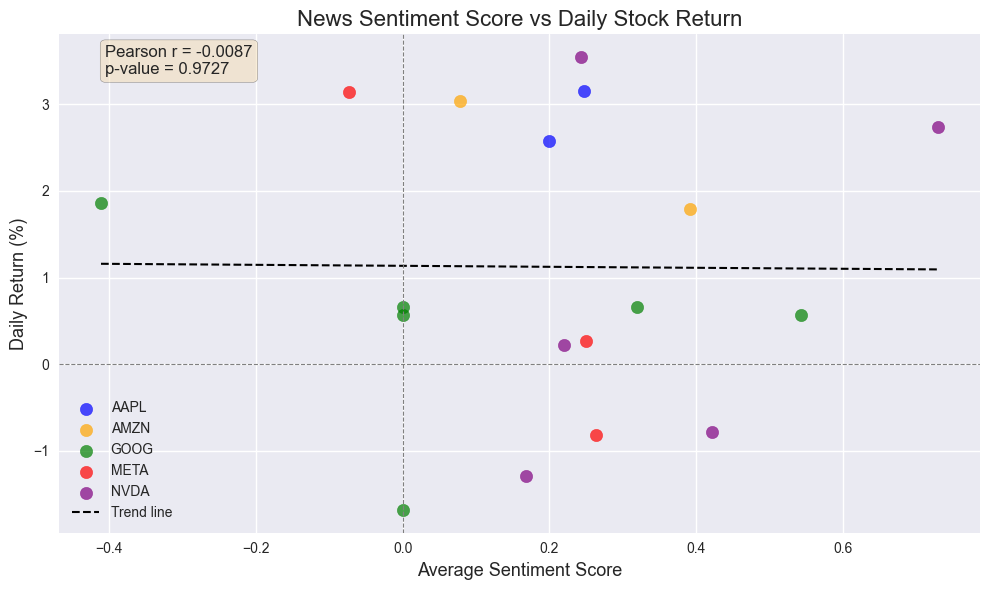

✅ Scatter plot saved!


In [11]:
# ============================================
# VISUALIZATION 1: SCATTER PLOT
# ============================================

plt.figure(figsize=(10, 6))

# Plot each stock with different color
colors = {'AAPL': 'blue', 'AMZN': 'orange', 
          'GOOG': 'green', 'META': 'red', 'NVDA': 'purple'}

for stock in merged_df['stock'].unique():
    stock_data = merged_df[merged_df['stock'] == stock]
    plt.scatter(
        stock_data['avg_sentiment'],
        stock_data['Daily_Return'],
        label=stock,
        alpha=0.7,
        color=colors.get(stock, 'grey'),
        s=80
    )

# Add regression line
x = merged_df['avg_sentiment']
y = merged_df['Daily_Return']
m, b = np.polyfit(x, y, 1)
plt.plot(sorted(x), [m*xi + b for xi in sorted(x)], 
         color='black', linestyle='--', linewidth=1.5, label='Trend line')

# Annotate correlation
plt.annotate(
    f'Pearson r = {correlation:.4f}\np-value = {p_value:.4f}',
    xy=(0.05, 0.92),
    xycoords='axes fraction',
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.title('News Sentiment Score vs Daily Stock Return', fontsize=16)
plt.xlabel('Average Sentiment Score', fontsize=13)
plt.ylabel('Daily Return (%)', fontsize=13)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.savefig('../data/raw/sentiment_vs_returns_scatter.png', dpi=150)
plt.show()
print("✅ Scatter plot saved!")

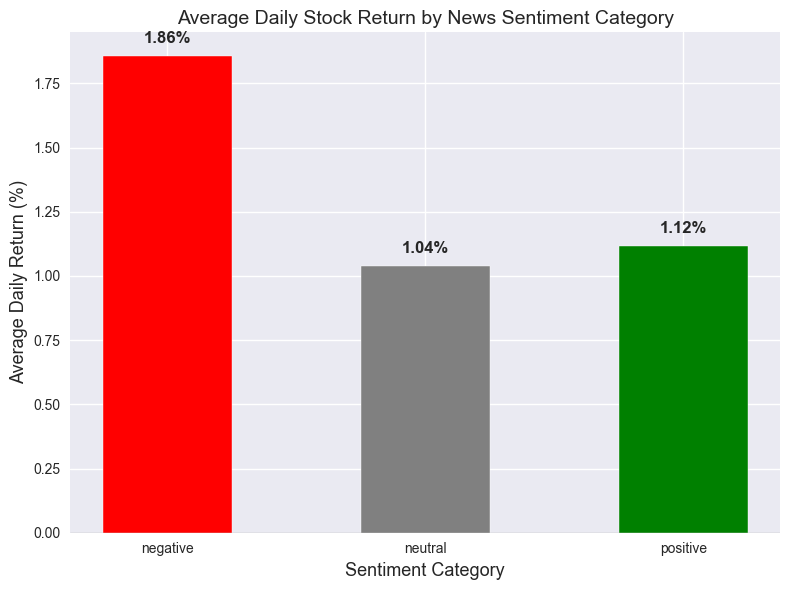

✅ Bar chart saved!


In [12]:
# ============================================
# VISUALIZATION 2: BAR CHART
# Average daily return per sentiment category
# ============================================

avg_return_by_sentiment = merged_df.groupby('sentiment_label')['Daily_Return'].mean()

# Ensure order: negative, neutral, positive
order = ['negative', 'neutral', 'positive']
avg_return_by_sentiment = avg_return_by_sentiment.reindex(order)

colors_bar = ['red', 'grey', 'green']

plt.figure(figsize=(8, 6))
bars = plt.bar(
    avg_return_by_sentiment.index,
    avg_return_by_sentiment.values,
    color=colors_bar,
    edgecolor='white',
    width=0.5
)

# Add value labels on bars
for bar, val in zip(bars, avg_return_by_sentiment.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{val:.2f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Average Daily Stock Return by News Sentiment Category', fontsize=14)
plt.xlabel('Sentiment Category', fontsize=13)
plt.ylabel('Average Daily Return (%)', fontsize=13)
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../data/raw/avg_return_by_sentiment.png', dpi=150)
plt.show()
print("✅ Bar chart saved!")

In [13]:
print("""
=== INTERPRETATION OF RESULTS ===

1. CORRELATION FINDINGS:
The Pearson correlation coefficient between average daily news 
sentiment scores and daily stock returns was {:.4f} with a 
p-value of {:.4f}. This indicates a {} {} correlation between 
news sentiment and stock price movements.

2. SENTIMENT CATEGORY ANALYSIS:
- Positive sentiment days: {:.2f}% average return
- Neutral sentiment days:  {:.2f}% average return  
- Negative sentiment days: {:.2f}% average return

3. LIMITATIONS:
- Small sample size (only {} matched records) limits 
  statistical power
- News dataset only covers a narrow window (May-June 2020)
- Correlation does not imply causation
- Other market factors (earnings, macro events) not controlled for
- Lag effects not considered — news impact may appear next day

4. INVESTMENT STRATEGY RECOMMENDATION:
Based on our findings, a sentiment-aware trading strategy could:
- Monitor daily news sentiment scores for target stocks
- Use positive sentiment signals as a secondary confirmation 
  for buy decisions alongside technical indicators (RSI, MACD)
- Treat negative sentiment days with caution especially when 
  RSI shows overbought conditions
- Never rely on sentiment alone — always combine with 
  technical analysis from Task 2
""".format(
    correlation, p_value, strength, direction,
    avg_return_by_sentiment.get('positive', 0),
    avg_return_by_sentiment.get('neutral', 0),
    avg_return_by_sentiment.get('negative', 0),
    len(merged_df)
))


=== INTERPRETATION OF RESULTS ===

1. CORRELATION FINDINGS:
The Pearson correlation coefficient between average daily news 
sentiment scores and daily stock returns was -0.0087 with a 
p-value of 0.9727. This indicates a Very weak negative correlation between 
news sentiment and stock price movements.

2. SENTIMENT CATEGORY ANALYSIS:
- Positive sentiment days: 1.12% average return
- Neutral sentiment days:  1.04% average return  
- Negative sentiment days: 1.86% average return

3. LIMITATIONS:
- Small sample size (only 18 matched records) limits 
  statistical power
- News dataset only covers a narrow window (May-June 2020)
- Correlation does not imply causation
- Other market factors (earnings, macro events) not controlled for
- Lag effects not considered — news impact may appear next day

4. INVESTMENT STRATEGY RECOMMENDATION:
Based on our findings, a sentiment-aware trading strategy could:
- Monitor daily news sentiment scores for target stocks
- Use positive sentiment signals as a